# Adiabatic error cancellation in Berry phase estimation

All experiments and figures for the paper, in one notebook. The reusable physics
lives in the `berry_cancellation` package (loop models + estimators); this notebook
only drives it and plots. Run top to bottom.

The cancellation cascade on a closed adiabatic loop:

| estimator | leading error |
|---|---|
| single evolution | $O(T^{-1})$ |
| forward&ndash;reverse (averages $\pm H$) | $O(T^{-2})$, oscillatory |
| + Richardson extrapolation | removes the non-oscillatory $T^{-2}$ |
| + runtime randomization ($C^\infty$ bump) | suppresses the oscillatory residual |

Each model figure combines, in one panel pair, the **Berry phase at a small runtime**
(left: the analytic value, the naive runtime-scaling estimate, and the full
protocol's estimate, at a small cheap $T$) and the **error-cancellation cascade vs
runtime** (right). Two
models: a spin-$1/2$ in a cone field (exactly solvable) and a spiral Heisenberg
chain (genuinely entangled many-qubit). A separate figure checks the analytic error
bounds and identifies which spectral gap controls each estimator. Every figure
carries a paper-ready description and caption in the markdown cell above it.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from berry_cancellation import SpinHalfLoop
from berry_cancellation.manybody import SpiralHeisenbergChain
from berry_cancellation.estimators import (
    single_phase_error, forward_reverse_error, richardson_error,
    randomized_richardson_bias, _theta_B_single, _theta_B_randomized,
)
from berry_cancellation.reference import wrap_to_pi, wrap_to_half_pi


def small_T_panel(ax, models, analytic, thetas, Tchk, lam, alpha, xlabel):
    "Berry phase vs cone angle at small T: analytic, runtime-scaling and 2R+bump estimates."
    analytic = np.asarray(analytic)
    est_rs, est_2r = [], []
    for m, raw in zip(models, analytic):
        s = _theta_B_single(m, Tchk)[0]                 # theta_B mod 2 pi
        est_rs.append(raw + float(wrap_to_pi(s - raw)))
        r = _theta_B_randomized(m, Tchk, alpha=alpha, lam=lam, levels=2, dist="bump")[0]
        est_2r.append(raw + float(wrap_to_half_pi(r - raw)))  # theta_B mod pi
    ax.plot(thetas, analytic, "-", lw=2, color="0.4", label="analytic")
    ax.plot(thetas, est_rs, "o", ms=6, color="C0", label="single evolution (runtime scaling)")
    ax.plot(thetas, est_2r, "D", ms=6, color="C3", label="2 Richardson + bump")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(r"Berry phase $\theta_B$  (rad)")
    ax.set_title(rf"(a) Berry phase vs cone angle at small $T={Tchk:.0f}$")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2)
    print(f"  T={Tchk:.0f}: single median dev={np.median(np.abs(np.array(est_rs)-analytic)):.1e}, "
          f"2R+bump median dev={np.median(np.abs(np.array(est_2r)-analytic)):.1e}")
    return est_rs, est_2r


def cascade_panel(ax, model, T, lam, alpha):
    "Plot the four-estimator error cascade for the model on a log-log axis."
    e_single = single_phase_error(model, T)
    e_fr = forward_reverse_error(model, T)
    e_b1 = randomized_richardson_bias(model, T, alpha=alpha, lam=lam, levels=1, dist="bump")
    e_b2 = randomized_richardson_bias(model, T, alpha=alpha, lam=lam, levels=2, dist="bump")
    ax.loglog(T, e_single, "o-", ms=5, color="C0", label=r"single  $|\varphi|$")
    ax.loglog(T, e_fr, "s-", ms=5, color="C1", label=r"forward--reverse")
    ax.loglog(T, e_b1, "^-", ms=5, color="C2", label=r"1 Richardson + bump")
    ax.loglog(T, e_b2, "D-", ms=5, color="C3", label=r"2 Richardson + bump")
    tail = T >= np.sqrt(T[0] * T[-1])
    for power, e, style in [(-1, e_single, ":"), (-2, e_fr, "--"),
                            (-4, e_b1, (0, (5, 1))), (-6, e_b2, "-.")]:
        c = np.median(e[tail] / T[tail] ** power)
        ax.loglog(T, c * T ** power, color="0.55", lw=1.0, linestyle=style,
                  label=rf"$\propto T^{{{power}}}$")
    ax.set_xlabel("runtime $T$")
    ax.set_ylabel(r"phase error  $|\tilde\theta_B - \theta_B|$  (rad)")
    ax.legend(fontsize=7, ncol=2, loc="lower left")
    ax.grid(True, which="both", alpha=0.2)

## 1. Spin-1/2 cone loop: small-runtime accuracy and the cancellation cascade

As a controlled testbed we use a spin-$1/2$ in a field of fixed magnitude swept
around a cone of half-angle $\theta_0$ on the Bloch sphere,
$H(s)=-\tfrac{1}{2}\mathbf{B}(s)\!\cdot\!\boldsymbol{\sigma}$, whose ground-state
Berry phase is known exactly, $\theta_B=-\pi(1-\cos\theta_0)$. Panel (a) shows the
value of the protocol at a *small, cheap* runtime $T=8$: a single adiabatic
evolution (the naive runtime-scaling estimate, error $\sim1/T$) is off by
$\sim10^{-1}$ rad across the whole range of cone angles, whereas the two-Richardson +
bump protocol recovers the exact Berry phase to $\sim10^{-2}$&ndash;$10^{-3}$ rad at
the same runtime. Panel (b) then traces the full cancellation cascade versus runtime
at $\theta_0=0.4\pi$ (gap $\Delta=1$): a single traversal errs at $O(T^{-1})$;
averaging the $\pm H$ eigenphases cancels the dynamical phase and the leading term,
leaving $O(T^{-2})$; a Richardson extrapolation removes the non-oscillatory $T^{-2}$
part and runtime randomization over a $C^\infty$ bump suppresses the oscillatory
residual super-polynomially, improving the scaling one level at a time to $O(T^{-4})$
and $O(T^{-6})$.

**Caption.** Spin-$1/2$ cone loop. **(a)** Berry phase $\theta_B$ versus cone
half-angle $\theta_0$ at a fixed small runtime $T=8$: the exact analytic value
$-\pi(1-\cos\theta_0)$ (line), the runtime-scaling estimate (a single adiabatic
evolution, $\circ$), and the two-Richardson + bump estimate ($\diamond$). At this
cheap runtime the single evolution departs from the analytic curve by $\sim1$ rad
while the protocol's estimate lies on it.
**(b)** Error-cancellation cascade versus runtime ($\theta_0=0.4\pi$, $\Delta=1$):
single evolution ($\circ$, $\propto T^{-1}$), forward&ndash;reverse ($\square$,
$\propto T^{-2}$), one Richardson level + bump randomization ($\triangle$,
$\propto T^{-4}$) and two levels ($\diamond$, $\propto T^{-6}$); grey lines are
reference slopes, $\lambda=0.7$, $\alpha=1.75$. The two-level curve sits at its
$T^{-6}$ floor and is oscillation-limited (its dips are zero crossings of the signed
bias).

spin-1/2 small-T comparison ...


  T=8: single median dev=1.0e+00, 2R+bump median dev=6.4e-03


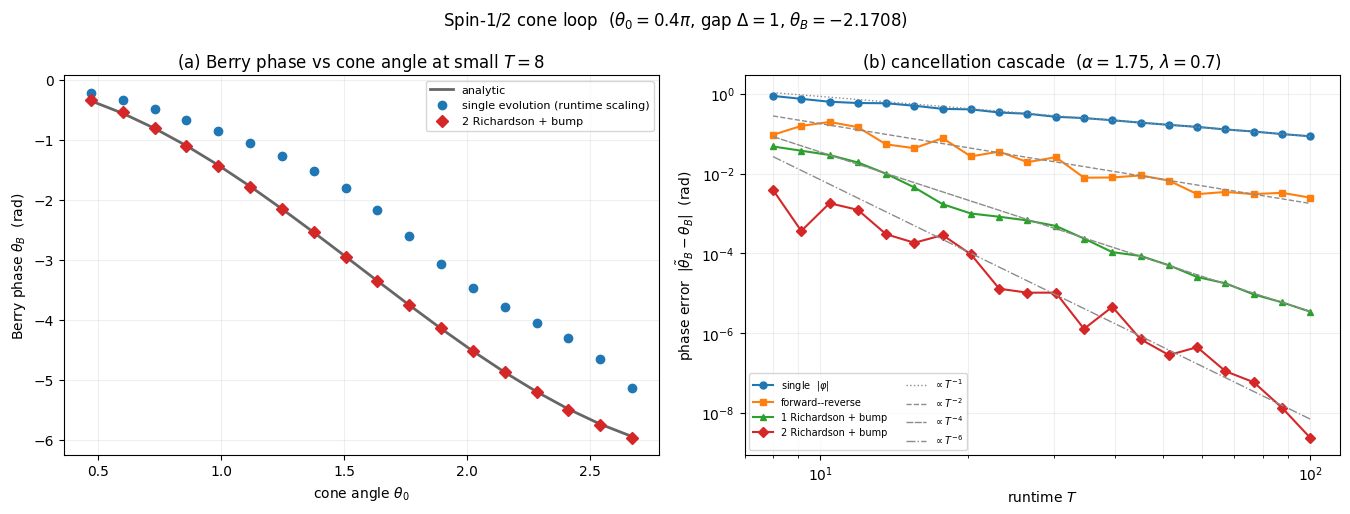

In [2]:
fig, (axA, axB) = plt.subplots(1, 2, figsize=(13.6, 5.2))
LAM, ALPHA = 0.7, 1.75
thetas = np.linspace(0.15 * np.pi, 0.85 * np.pi, 18)

# (a) Berry phase vs cone angle at a small, cheap runtime: runtime-scaling vs protocol.
print("spin-1/2 small-T comparison ...")
models = [SpinHalfLoop(theta0=float(th)) for th in thetas]
analytic = [m.berry_phase for m in models]
small_T_panel(axA, models, analytic, thetas, 8.0, LAM, ALPHA, r"cone angle $\theta_0$")

# (b) error-cancellation cascade vs runtime.
model = SpinHalfLoop()
T = np.geomspace(8.0, 100.0, 20)
cascade_panel(axB, model, T, LAM, ALPHA)
axB.set_xlim(7.0, 115.0)
axB.set_title(rf"(b) cancellation cascade  ($\alpha={ALPHA:g}$, $\lambda={LAM:g}$)")

fig.suptitle(rf"Spin-1/2 cone loop  ($\theta_0=0.4\pi$, gap $\Delta=1$, "
             rf"$\theta_B={model.berry_phase:.4f}$)", fontsize=12)
fig.tight_layout()
plt.show()

## 2. Theory bounds, and which gap controls each estimator (spin-1/2)

To check the analytic error bounds and, in particular, to identify *which* spectral
gap governs each stage of the cascade, we deform the loop into a non-isospectral one
by modulating the field magnitude, $|B(s)| = |B|\,(1 - a\sin^2\pi s)$ with $a=0.4$.
This lowers the gap in the *interior* of the loop to $\Delta_{\min}=0.6$ while
leaving the *endpoint* quantities &mdash; the gap $\Delta(0)=1$ and the rate
$\|\dot H(0)\|$ &mdash; unchanged, and it leaves the Berry phase invariant
(panel a). The single-evolution error is set by the interior worst-case gap:
$|\varphi|\lesssim \|\dot H\|_{\max}^2/(\Delta_{\min}^3\,T)$, so the dip raises both
the numerics and (more steeply) the bound (panel b). The Richardson residual, in
contrast, is an endpoint-controlled boundary term $\sim\|\dot H(0)\|^2/(\Delta(0)^4
T^2)$: the dipped and undipped data fall on the *same* line, independent of the
interior gap (panel c). Finally the randomized one-Richardson bias obeys the
Theorem-3 estimate, which for a $C^\infty$ bump (effective $M=2$) reads
$C\,\|\dot H(0)\|^2/(\Delta(0)^4\,\Delta_{\min}^2\,T^4)$; a single constant
$C\approx48$ upper-bounds both curves (panel d), confirming the joint dependence on
the endpoint gap $\Delta(0)$ and the interior gap $\Delta_{\min}$.

**Caption.** Numerics against the analytic bounds, and the controlling gap for each
estimator, on a non-isospectral spin-$1/2$ loop with field modulation
$|B(s)|=|B|(1-a\sin^2\pi s)$, $a=0.4$. (a) Instantaneous gap $\Delta(s)$: constant
($a=0$, dashed) versus dipped to $\Delta_{\min}=0.6$ in the interior (solid), with
the endpoints fixed at $\Delta(0)=1$. (b) Single-evolution error with the worst-case
bound $\|\dot H\|_{\max}^2/(\Delta_{\min}^3 T)$ for the dipped and undipped loops:
the error tracks the *interior* gap $\Delta_{\min}$. (c) One-Richardson residual:
dipped and undipped data collapse onto the same endpoint-controlled line
$\|\dot H(0)\|^2/(\Delta(0)^4 T^2)$, independent of $\Delta_{\min}$. (d) One
Richardson with bump randomization and the Theorem-3 ($M=2$) upper bound
$C\,\|\dot H(0)\|^2/(\Delta(0)^4\Delta_{\min}^2 T^4)$; one constant $C\approx48$
bounds both loops. $T\in[20,400]$.

upper-bound constant C=47.9


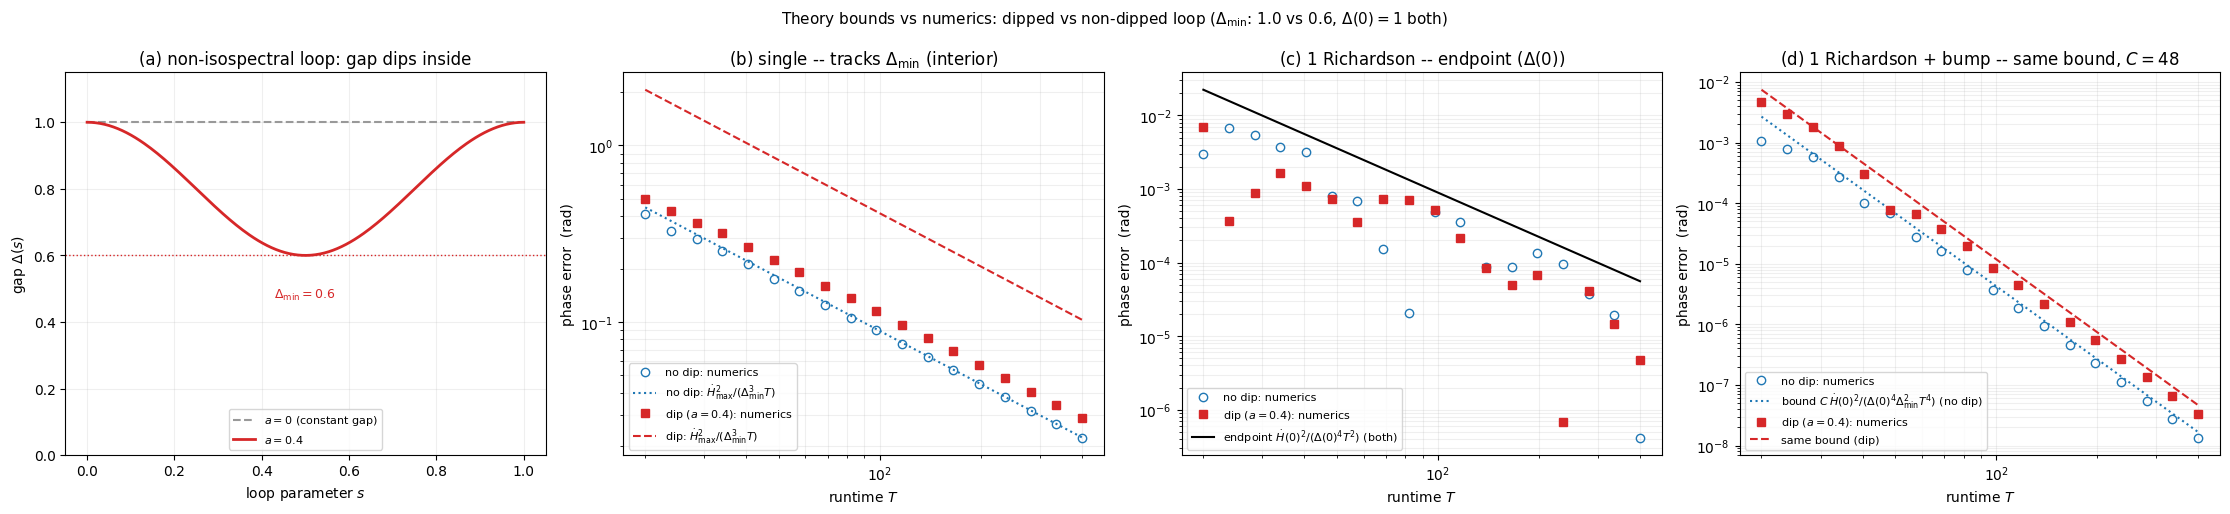

In [3]:
A = 0.4
T_MIN, T_MAX, N_POINTS = 20.0, 400.0, 18

def hdot_norm(model, s, h=1e-6):
    return np.linalg.norm(model.H(s + h) - model.H(s - h), 2) / (2 * h)

def info(model):
    s = np.linspace(0.0, 1.0, 400, endpoint=False)
    Hmax = max(hdot_norm(model, si) for si in s)
    return Hmax, model.gap, hdot_norm(model, 0.0), model.gap_at(0.0)

T = np.geomspace(T_MIN, T_MAX, N_POINTS)
flat = SpinHalfLoop(gap_dip=0.0)
dip = SpinHalfLoop(gap_dip=A)
Hmf, Dmf, H0f, D0f = info(flat)
Hmd, Dmd, H0d, D0d = info(dip)

fig, (ax0, axL, axR, axC) = plt.subplots(1, 4, figsize=(22.4, 5.2))

# Panel 0: the dipping gap Delta(s) along the loop.
s = np.linspace(0.0, 1.0, 200)
ax0.plot(s, np.ones_like(s) * flat.field, "--", color="0.6", label=r"$a=0$ (constant gap)")
ax0.plot(s, [dip.gap_at(si) for si in s], "-", color="C3", lw=2, label=rf"$a={A}$")
ax0.axhline(dip.gap, color="C3", ls=":", lw=1)
ax0.annotate(rf"$\Delta_{{\min}}={dip.gap:.1f}$", xy=(0.5, dip.gap),
             xytext=(0.5, dip.gap - 0.13), ha="center", fontsize=9, color="C3")
ax0.set_xlabel("loop parameter $s$")
ax0.set_ylabel(r"gap $\Delta(s)$")
ax0.set_title(r"(a) non-isospectral loop: gap dips inside")
ax0.set_ylim(0, 1.15)
ax0.legend(loc="lower center", fontsize=8)
ax0.grid(True, alpha=0.2)

# Panel 1: single evolution, dip vs no dip.
axL.loglog(T, single_phase_error(flat, T), "o", ms=6, mfc="none", color="C0", label="no dip: numerics")
axL.loglog(T, Hmf**2 / Dmf**3 / T, ":", color="C0", lw=1.5, label=r"no dip: $\dot H_{\max}^2/(\Delta_{\min}^3 T)$")
axL.loglog(T, single_phase_error(dip, T), "s", ms=6, color="C3", label=rf"dip ($a={A}$): numerics")
axL.loglog(T, Hmd**2 / Dmd**3 / T, "--", color="C3", lw=1.5, label=r"dip: $\dot H_{\max}^2/(\Delta_{\min}^3 T)$")
axL.set_xlabel("runtime $T$")
axL.set_ylabel(r"phase error  (rad)")
axL.set_title(r"(b) single -- tracks $\Delta_{\min}$ (interior)")
axL.legend(fontsize=8, loc="lower left")
axL.grid(True, which="both", alpha=0.2)

# Panel 2: 1 Richardson, dip vs no dip.
axR.loglog(T, richardson_error(flat, T), "o", ms=6, mfc="none", color="C0", label="no dip: numerics")
axR.loglog(T, richardson_error(dip, T), "s", ms=6, color="C3", label=rf"dip ($a={A}$): numerics")
axR.loglog(T, H0d**2 / D0d**4 / T**2, "-", color="k", lw=1.5, label=r"endpoint $\dot H(0)^2/(\Delta(0)^4 T^2)$ (both)")
axR.set_xlabel("runtime $T$")
axR.set_ylabel(r"phase error  (rad)")
axR.set_title(r"(c) 1 Richardson -- endpoint ($\Delta(0)$)")
axR.legend(fontsize=8, loc="lower left")
axR.grid(True, which="both", alpha=0.2)

# Panel 3: 1 Richardson + bump randomization, with the Theorem-3 (M=2) upper bound.
bf = randomized_richardson_bias(flat, T, alpha=1.75, lam=0.7, levels=1, dist="bump")
bd = randomized_richardson_bias(dip, T, alpha=1.75, lam=0.7, levels=1, dist="bump")
base_f = H0f**2 / D0f**4 / Dmf**2
base_d = H0d**2 / D0d**4 / Dmd**2
C = max(np.max(bf * T**4 / base_f), np.max(bd * T**4 / base_d))
bound_f, bound_d = C * base_f / T**4, C * base_d / T**4
print(f"upper-bound constant C={C:.1f}")
axC.loglog(T, bf, "o", ms=6, mfc="none", color="C0", label="no dip: numerics")
axC.loglog(T, bound_f, ":", color="C0", lw=1.5, label=r"bound $C\,\dot H(0)^2/(\Delta(0)^4\Delta_{\min}^2 T^4)$ (no dip)")
axC.loglog(T, bd, "s", ms=6, color="C3", label=rf"dip ($a={A}$): numerics")
axC.loglog(T, bound_d, "--", color="C3", lw=1.5, label=r"same bound (dip)")
axC.set_xlabel("runtime $T$")
axC.set_ylabel(r"phase error  (rad)")
axC.set_title(rf"(d) 1 Richardson + bump -- same bound, $C={C:.0f}$")
axC.legend(fontsize=8, loc="lower left")
axC.grid(True, which="both", alpha=0.2)

fig.suptitle(rf"Theory bounds vs numerics: dipped vs non-dipped loop ($\Delta_{{\min}}$: 1.0 vs {Dmd:.1f}, $\Delta(0)=1$ both)", fontsize=11)
fig.tight_layout()
plt.show()

## 3. Entangled many-qubit loop: small-runtime accuracy and the cancellation cascade

We repeat the programme on a genuinely interacting model: a four-site Heisenberg
chain $H(s)=-\sum_i\mathbf{B}_i(s)\!\cdot\!\mathbf{S}_i+J\sum_{\langle ij\rangle}
\mathbf{S}_i\!\cdot\!\mathbf{S}_j$ ($J=1$) with a site-dependent azimuthal offset
$\phi_i=2\pi i/N$ (a "spiral"), which breaks the global spin-rotation symmetry so the
ground state is entangled and the virtual-excitation contribution to the phase error
is nonzero &mdash; a true many-body test. The rigid global rotation underlying the
loop gives an exact propagator and a closed-form Berry phase
$\theta_B=2\pi\langle S^z_{\rm tot}\rangle_0$ (taken as the reference). Panel (a)
again plots the Berry phase itself versus cone angle at a small runtime $T=20$,
comparing the naive runtime-scaling estimate (a single adiabatic evolution) with the
two-Richardson + bump protocol (the gap varies over $[0.11,0.42]$ across the sweep):
the single evolution departs visibly from the analytic
$2\pi\langle S^z_{\rm tot}\rangle_0$ while the protocol's estimate lies on it. Panel
(b) applies the same four
estimators unchanged and reproduces the full hierarchy $O(T^{-1})\to O(T^{-2})\to
O(T^{-4})\to O(T^{-6})$ at $\theta=0.4\pi$ (gap $=0.37$); the smaller gap enlarges the
prefactors, so we take $T\in[20,200]$ and a wider window $\lambda=0.8$
($\lambda\Delta_{\min}T\gtrsim1$). The cancellation thus persists for a genuinely
entangled many-qubit adiabatic loop.

**Caption.** Entangled spiral Heisenberg chain ($N=4$, $J=1$, $B_0=1$). **(a)**
Berry phase $\theta_B$ versus cone angle $\theta$ at a fixed small runtime $T=20$:
the exact analytic value $2\pi\langle S^z_{\rm tot}\rangle_0$ (line), the
runtime-scaling estimate (a single adiabatic evolution, $\circ$), and the
two-Richardson + bump estimate ($\diamond$); the single evolution departs from the
curve while the protocol lies on it (the gap over the sweep lies in $[0.11,0.42]$).
**(b)** Error-cancellation cascade versus runtime ($\theta=0.4\pi$,
gap $=0.37$, $\theta_B=1.4530$) with the same four estimators as in Fig. 1(b)
($\circ\,T^{-1}$, $\square\,T^{-2}$, $\triangle\,T^{-4}$, $\diamond\,T^{-6}$; grey
reference slopes), $\alpha=1.75$, $\lambda=0.8$. The smaller gap pushes the clean
$T^{-6}$ regime to larger $T$.

many-body small-T comparison ...


  T=20: single median dev=8.3e-01, 2R+bump median dev=6.1e-04
  gap range over sweep: [0.109, 0.415]


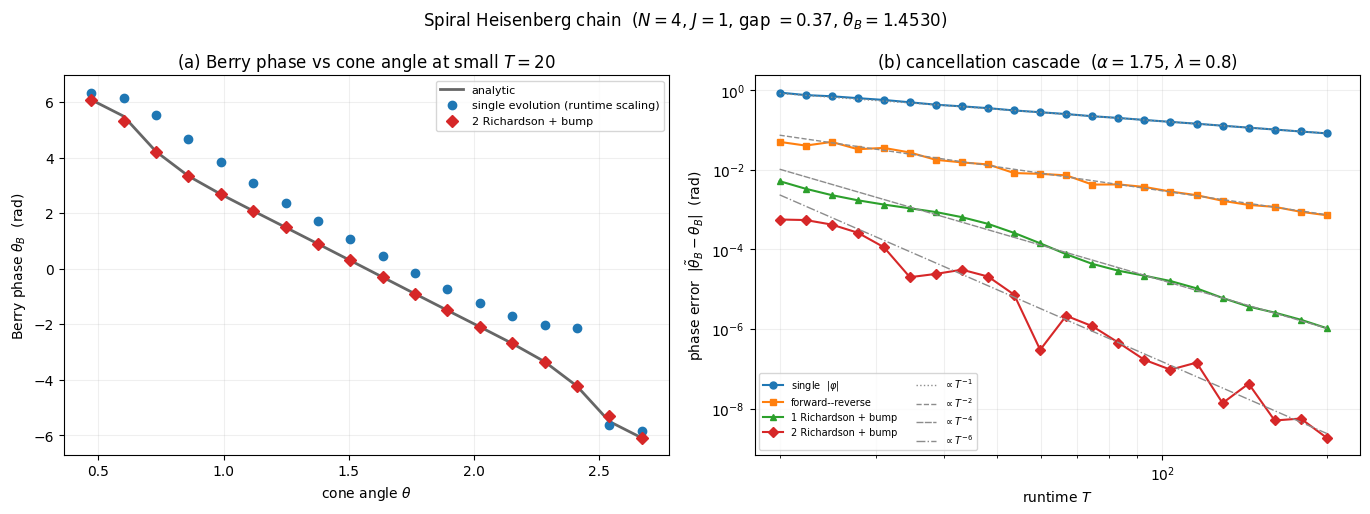

In [4]:
fig, (axA, axB) = plt.subplots(1, 2, figsize=(13.8, 5.2))
N, J, B0 = 4, 1.0, 1.0
LAM, ALPHA = 0.8, 1.75
thetas = np.linspace(0.15 * np.pi, 0.85 * np.pi, 18)

# (a) Berry phase vs cone angle at a small, cheap runtime: runtime-scaling vs protocol.
print("many-body small-T comparison ...")
models = [SpiralHeisenbergChain(N=N, J=J, B0=B0, theta=float(th)) for th in thetas]
analytic = [2.0 * np.pi * float(np.real(m.psi0.conj() @ m.Sz_tot @ m.psi0)) for m in models]
small_T_panel(axA, models, analytic, thetas, 20.0, LAM, ALPHA, r"cone angle $\theta$")
print(f"  gap range over sweep: [{min(m.gap for m in models):.3f}, {max(m.gap for m in models):.3f}]")

# (b) error-cancellation cascade vs runtime.
model = SpiralHeisenbergChain(N=N, J=J, B0=B0, theta=0.4 * np.pi)
T = np.geomspace(20.0, 200.0, 22)
cascade_panel(axB, model, T, LAM, ALPHA)
axB.set_xlim(18.0, 230.0)
axB.set_title(rf"(b) cancellation cascade  ($\alpha={ALPHA:g}$, $\lambda={LAM:g}$)")

fig.suptitle(rf"Spiral Heisenberg chain  ($N={N}$, $J={J:g}$, gap $={model.gap:.2f}$, "
             rf"$\theta_B={model.berry_phase:.4f}$)", fontsize=12)
fig.tight_layout()
plt.show()